## Introducción

Objetivo del proyecto: **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Datos: de TomTom Traffic Index y OECD Cities.

## 🧩 Paso 1: Cargar y explorar

**Familiarizarte con la estructura de ambos datasets**, etapa para validar que los archivos se carguen correctamente, exploración de columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

Importar las librerías necesarias.


In [151]:
# importar librerías
import pandas as pd  
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [152]:
# cargar archivos
traffic = pd.read_csv('C:/Users/Nardus/Downloads/tomtom_traffic.csv')
eco = pd.read_csv('C:/Users/Nardus/Downloads/oecd_city_economy.csv')   #completa el código

In [153]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [154]:

# mostrar las primeras 5 filas de eco
eco.head(5)


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Inspeccionar su estructura, tipos de datos, columnas y valores faltantes.
Realizar limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos


  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [155]:
# Examinar la estructura de traffic
traffic.info(3)

<class 'pandas.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  str    
 1   City                            1004464 non-null  str    
 2   UpdateTimeUTC                   1004464 non-null  str    
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  str    
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtypes: float64(

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo OBJECT


In [156]:
# Examinar la estructura de eco
eco.info(3)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             30 non-null     int64
 1   City             30 non-null     str  
 2   Country          30 non-null     str  
 3   City GDP/capita  30 non-null     str  
 4   Unemployment %   30 non-null     str  
 5   PM2.5 (μg/m³)    30 non-null     str  
 6   Population (M)   30 non-null     str  
dtypes: int64(1), str(6)
memory usage: 1.8 KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (µg/m³)` y `Population (M)` deberían ser numéricas pero están como tipo str, probablemente porque contienen símbolos o caracteres no numéricos.
- No hay valores nulos (Non-Null Count = 30 en todas), así que el problema no es de datos faltantes sino de formato/tipo de dato.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [157]:
print(traffic.shape)      # te dice (filas, columnas)
print(traffic.columns.tolist())   # te muestra los nombres actuales, en orden

(1004464, 12)
['Country', 'City', 'UpdateTimeUTC', 'JamsDelay', 'TrafficIndexLive', 'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo', 'UpdateTimeUTCWeekAgo', 'TravelTimeLivePer10KmsMins', 'TravelTimeHistoricPer10KmsMins', 'MinsDelay']


In [158]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = [
    'country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live',
    'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago',
    'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins', 'mins_delay'] #tu código aquí

# verificar cambios
traffic.columns




Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='str')

In [159]:

# Estandarizar los nombres de las columnas de eco


eco.columns = [
    'year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct', 'pm25_ug_m3', 
    'population_m']#tu código aquí

# verificar cambios
eco.columns




Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_ug_m3', 'population_m'],
      dtype='str')


### 2.3 Corregir formatos numéricos y de fecha

Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.


In [160]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()

traffic['update_time_utc'] = pd.to_datetime (traffic['update_time_utc'], errors='coerce') #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime (traffic['update_time_utc_week_ago'], errors='coerce') #tu código aquí

# verificar el cambio
traffic.info()


<class 'pandas.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  str           
 1   city                                 1004464 non-null  str           
 2   update_time_utc                      1004464 non-null  datetime64[us]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[us]
 9   travel_time_live_per_10kms_mins      1004464 non-null  float64      

In [161]:


# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)



<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     str    
 2   country           30 non-null     str    
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25_ug_m3        30 non-null     str    
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_ug_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

Identificar el año de cada registro y mantener solo los registros del 2024.



In [162]:

# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic ['update_time_utc'].dt.year

# Verificar cambio

traffic.head(3)



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [163]:


# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())




,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_ug_m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Calcular los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.


In [164]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[
    ['jams_delay', 'traffic_index_live', 'jams_length_in_kms', 
     'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 
     'travel_time_historic_per_10kms_mins']
    ].mean().reset_index()
# tu código aqui

# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?


In [165]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Mexico City


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.




In [166]:


# Seleccionar columnas clave de tráfico y economía
left_cols = ['city',
             'country',
             'year',
             'jams_delay',
             'traffic_index_live',
             'jams_length_in_kms',
             'jams_count','mins_delay',
             'travel_time_live_per_10kms_mins',
             'travel_time_historic_per_10kms_mins']


right_cols = ['city',
              'year',
              'city_gdp_capita',
              'unemployment_pct',
              'pm25_ug_m3',
              'population']


# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, 
                  eco_2024_small, 
                  on=['city', 'year'], 
                  how='inner')# tu código aquí

# Mostrar las primeras 5 filas
merged.head(5)
# tu código aquí



,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25_ug_m3,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

 **visualizar patrones**: Los gráficos ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

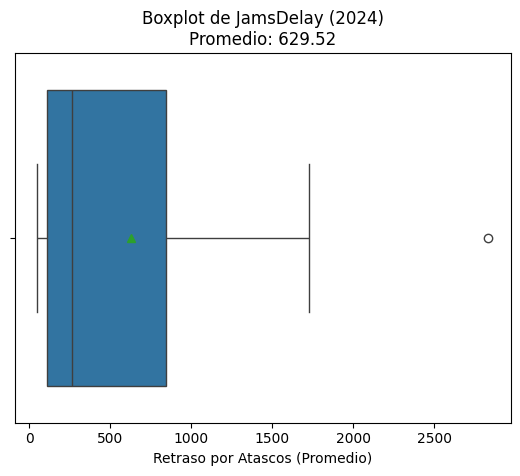

In [171]:





# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(x=merged['jams_delay'], 
            showmeans=True)
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Retraso por Atascos (Promedio)')
plt.show()







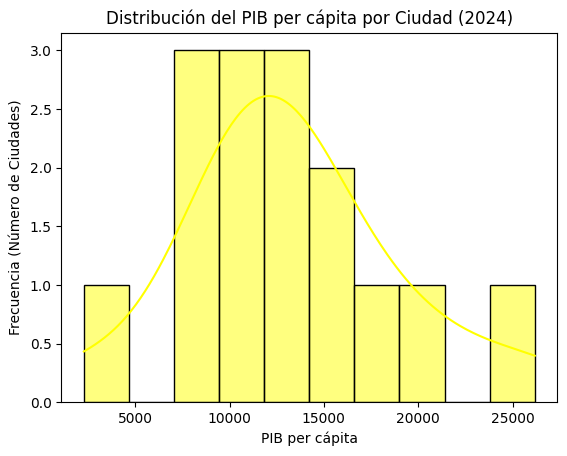

In [172]:



# Crear histograma para ver la distribución de la economía (city_gdp_capita)

sns.histplot(merged['city_gdp_capita'],
             bins=10, 
             kde=True, 
             color='yellow')

plt.title('Distribución del PIB per cápita por Ciudad (2024)')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia (Número de Ciudades)')
plt.show()






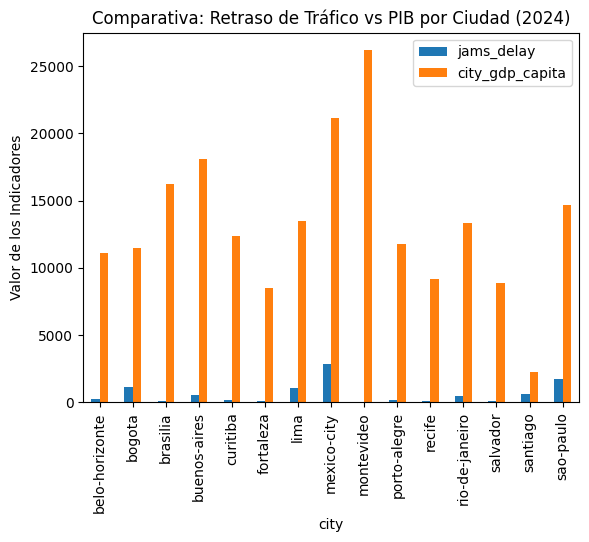

In [173]:



# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(x='city', 
            y=['jams_delay', 'city_gdp_capita'],
            kind ='bar',
        )

plt.title('Comparativa: Retraso de Tráfico vs PIB por Ciudad (2024)')
plt.ylabel('Valor de los Indicadores')
plt.xticks(rotation=90)
plt.show()








### 🧠 **Reflexión**

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?


---

## 🧩Paso 7: Exportar y documentar resultados
Guardar el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.



In [174]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)





---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios)
.
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).






---



# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
   Después de realizar el análisis de los datos de 2024, la conclusión es que no existe una relación lineal o directa entre la movilidad y la productividad económica, ciudades como la Ciudad de México demuestran que se puede tener una congestión crítica sin tener el PIB per cápita más alto, lo que sugiere que el tráfico aquí es un freno a la productividad.
   En lugar de una línea recta, observamos un fenómeno de 'desarrollo desigual'.

- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
  1.- jams_delay (Retraso por atascos) indicador de pérdida de tiempo, esto representa dinero perdido. Un jams_delay alto indica que la ciudad es ineficiente y que los ciudadanos tienen menos tiempo para el consumo, el       descanso o el trabajo.
  2.- traffic_index_live - Mide la intensidad del tráfico en tiempo real. Es vital para planificar horarios de transporte público y logística de carga.
  3.- city_gdp_capita (PIB per cápita) idndicador de la productividad promedio, que al compararlo con el tráfico, ayuda a identificar si la infraestructura de la ciudad está ayudando o no al crecimiento económico.
  4.- Population que sirve como variable de contexto y a entender si el tráfico es un problema de ciudades muy grandes o ciudades pequeñas con mucho tráfico.
  
**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.
  El análisis se centro unicamente en el año 2024
  Número de ciudades: Se incluyeron 30 ciudades globales.
  Número de países: El análisis abarca 24 países diferentes.
  

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
  Paso 1: estandarizamos las columnas con el formato snake_case, para eliminar espacion y caractreres esperciales, facilitando la escritura de código.
          Corregimos los formatos de las fechas y los convertimos de texto a objeto tipo datetime64 y convertir los formatos númericos que aparecian como texto a float para poer realizar cálculos mátematicos.

- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
  Utilice la funcion de agregación 'merge' para poder comparar dos fuentes distintas a detalle. Uniendo INNER. 

- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).
  Empleamos gráficos para validad la calidad de los datos y poder identificar patrones, usando histogramas para análisar como se reparte el PID entre las ciudades. Identificando outliers con el diagrama de caja
  detentamos valores atípicos.
  Y pudimos observar visualmente en nuestra gráfico de barras la falta de una relación lineal directa, confirmando que la riqueza no es el único motor de la congestión (tendencia general)
  
**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
 Desconexión de Riqueza y Movilidad ya que no existe una correlación lineal positiva fuerte. Ciudades con un PIB per cápita moderado a menudo presentan una congestión mucho más alta que las capitales financieras más
 ricas. Esto sugiere que el tráfico está más ligado a la falta de infraestructura de transporte masivo que al nivel de ingresos.
   
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
  En el diagrama de cajas identifique casos que se salen totalmente de la norma:
    *El Outlier Maestro: Ciudad de México (MEX):  Presenta un jams_delay de 2,833.05, el más alto de todo el dataset, superando por mucho a ciudades con economías más grandes.
    *Anomalía 2: Ciudades como Abu Dhabi muestran un PIB per cápita muy elevado pero con niveles de congestión.

**Recomendaciones**  

Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

En el resultado del análisis, la Ciudad de México surge como el caso más crítico y prioritario. CDMX muestra la mayor correlación negativa ya que es la ciudad con el índice de congestión más alto del estudio (jams_delay > 2,800), pero su PIB per cápita es significativamente inferior al de ciudades europeas o estadounidenses con tráficos menores. Ciudad de México sería la opción mas viable para recibir inversión urgente. Bogotá y Lima muestran un comportamiento similar pero menor.
